In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

In [18]:
file_path = r"C:\Users\sjs93\OneDrive - University of Florida\Desktop\HabDis_UT_CM_pilot1_mp4_5.6.26\HabDis_UT_CM_pilot1_5.6.26AllData.xlsx"
df = pd.read_excel(file_path)
# Use ALL mice (raw dataset)
df = pd.read_excel(
    file_path,
    sheet_name="Social_Interaction_s"
)


In [19]:
df.head()

,Subject,Condition,Exposure,SocialInteraction_s
0,1_1_s_1_2_cm_UT_d1,UrineTransfer,exp1,11.086
1,1_1_s_1_2_cm_UT_d1,UrineTransfer,exp2,10.106
2,1_1_s_1_2_cm_UT_d1,UrineTransfer,exp3,14.185
3,1_1_s_1_2_cm_UT_d1,UrineTransfer,exp4,9.448
4,1_1_s_1_2_cm_UT_d1,UrineTransfer,exp5,64.765


In [12]:
# Pivot dataframe
pivot = df.pivot_table(
    index=["Subject", "Condition"],
    columns="Exposure",
    values="SocialInteraction_s"
).reset_index()

pivot.head()

Exposure,Subject,Condition,exp1,exp2,exp3,exp4,exp5
0,1_1_s_1_2_cm_UT_d1,UrineTransfer,11.086,10.106,14.185,9.448,64.765
1,1_1_s_1_2_cm_saline_d2,Saline,6.623,4.112,4.062,5.455,23.071
2,1_2_s_1_1_cm_UT_d2,UrineTransfer,11.000,6.400,15.758,4.464,37.262
3,1_2_s_1_1_cm_saline_d1,Saline,14.495,6.254,14.222,11.264,17.664
4,1_3_s_1_4_cm_UT_d1,UrineTransfer,12.046,5.357,9.304,2.544,16.363


In [13]:
# Mean habituation baseline
pivot["HabituationMean_1to4"] = pivot[
    ["exp1", "exp2", "exp3", "exp4"]
].mean(axis=1)

# Dishabituation score
pivot["DishabituationScore"] = (
    pivot["exp5"] - pivot["HabituationMean_1to4"]
)

pivot[[
    "Subject",
    "Condition",
    "HabituationMean_1to4",
    "exp5",
    "DishabituationScore"
]]

Exposure,Subject,Condition,HabituationMean_1to4,exp5,DishabituationScore
0,1_1_s_1_2_cm_UT_d1,UrineTransfer,11.20625,64.765,53.55875
1,1_1_s_1_2_cm_saline_d2,Saline,5.06300,23.071,18.00800
2,1_2_s_1_1_cm_UT_d2,UrineTransfer,9.40550,37.262,27.85650
3,1_2_s_1_1_cm_saline_d1,Saline,11.55875,17.664,6.10525
4,1_3_s_1_4_cm_UT_d1,UrineTransfer,7.31275,16.363,9.05025
5,1_3_s_1_4_cm_saline_d2,Saline,4.46300,4.061,-0.40200
6,1_4_s_1_3_cm_UT_d2,UrineTransfer,4.69950,21.597,16.89750
7,1_4_s_1_3_cm_saline_d1,Saline,4.84225,6.848,2.00575
8,2_1_s_2_2_cm_UT_d1,UrineTransfer,6.84575,14.127,7.28125
9,2_1_s_2_2_cm_saline_d2,Saline,11.11000,15.824,4.71400


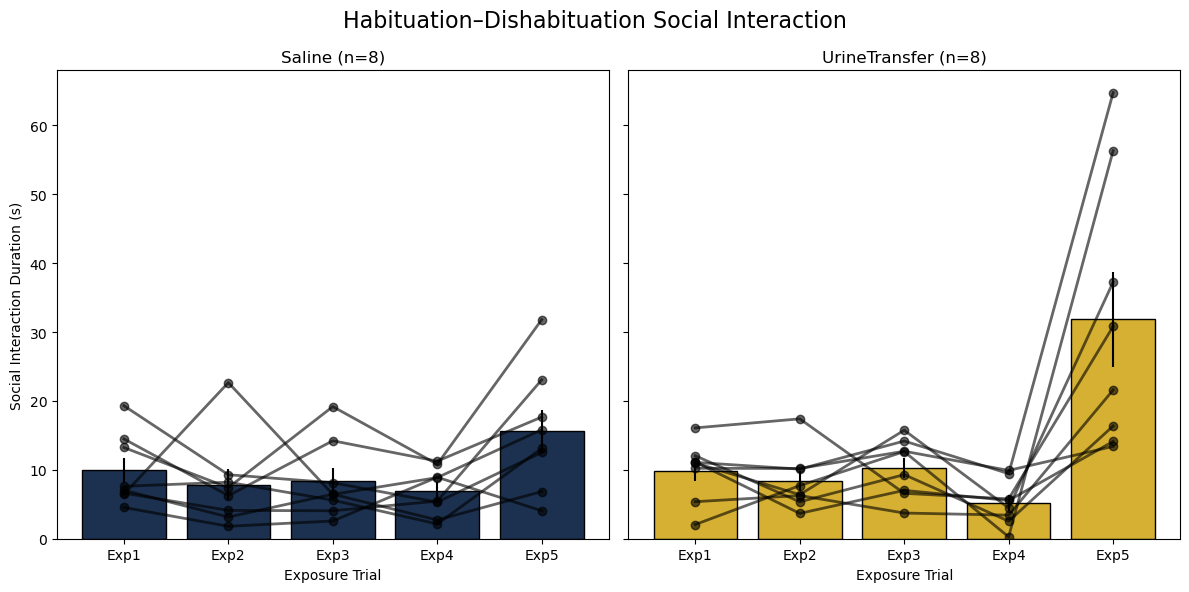

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# order exposures
exp_order = ["exp1", "exp2", "exp3", "exp4", "exp5"]

df["Exposure"] = pd.Categorical(
    df["Exposure"],
    categories=exp_order,
    ordered=True
)

# Padilla lab colors
padilla_navy = (28/255, 48/255, 79/255)
padilla_gold = (213/255, 176/255, 50/255)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12,6),
    sharey=True
)

conditions = ["Saline", "UrineTransfer"]
colors = [padilla_navy, padilla_gold]

for ax, cond, color in zip(
    axes,
    conditions,
    colors
):

    cond_df = df[
        df["Condition"] == cond
    ]

    # group means
    means = cond_df.groupby(
        "Exposure",
        observed=False
    )["SocialInteraction_s"].mean().reindex(exp_order)

    # SEM
    sems = cond_df.groupby(
        "Exposure",
        observed=False
    )["SocialInteraction_s"].sem().reindex(exp_order)

    x = np.arange(len(exp_order))

    # bar plot
    ax.bar(
        x,
        means.values,
        yerr=sems.values,
        color=color,
        edgecolor='black',
        zorder=1
    )

    # connect subjects across trials
    for subj, subdf in cond_df.groupby("Subject"):

        subdf = subdf.sort_values("Exposure")

        ax.plot(
            x,
            subdf["SocialInteraction_s"].values,
            marker='o',
            linewidth=2,
            color='black',
            alpha=0.6,
            zorder=2
        )

    ax.set_xticks(x)

    ax.set_xticklabels([
        "Exp1",
        "Exp2",
        "Exp3",
        "Exp4",
        "Exp5"
    ])

    ax.set_title(
        f"{cond} (n={cond_df['Subject'].nunique()})"
    )

    ax.set_xlabel("Exposure Trial")

axes[0].set_ylabel(
    "Social Interaction Duration (s)"
)

fig.suptitle(
    "Habituation–Dishabituation Social Interaction",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [14]:
from scipy.stats import ttest_ind

saline = pivot[
    pivot["Condition"] == "Saline"
]["DishabituationScore"]

ut = pivot[
    pivot["Condition"] == "UrineTransfer"
]["DishabituationScore"]

t, p = ttest_ind(
    ut,
    saline,
    equal_var=False
)

print("t =", t)
print("p =", p)

t = 2.1921603825527827
p = 0.05613647356107469


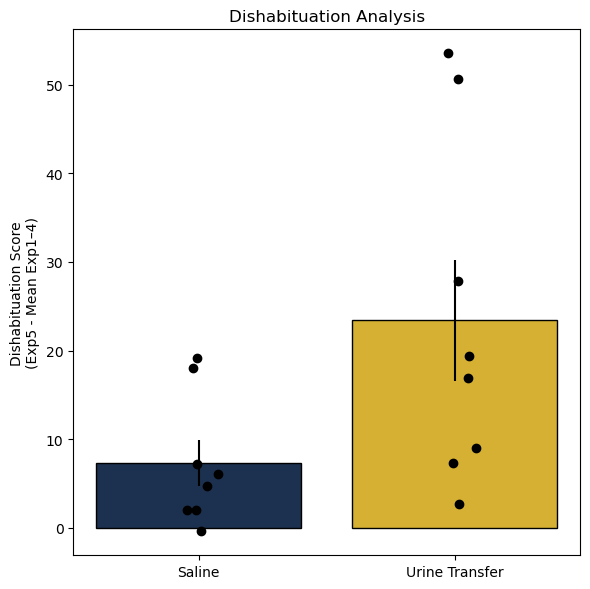

In [15]:
import matplotlib.pyplot as plt
import numpy as np

padilla_navy = (28/255, 48/255, 79/255)
padilla_gold = (213/255, 176/255, 50/255)

fig, ax = plt.subplots(figsize=(6,6))

means = [
    saline.mean(),
    ut.mean()
]

sems = [
    saline.sem(),
    ut.sem()
]

x = np.arange(2)

ax.bar(
    x,
    means,
    yerr=sems,
    color=[padilla_navy, padilla_gold],
    edgecolor='black'
)

# individual mice
for i, vals in enumerate([saline, ut]):

    jitter = np.random.normal(
        0,
        0.03,
        size=len(vals)
    )

    ax.scatter(
        np.full(len(vals), i) + jitter,
        vals,
        color='black',
        zorder=10
    )

ax.set_xticks(x)
ax.set_xticklabels([
    "Saline",
    "Urine Transfer"
])

ax.set_ylabel(
    "Dishabituation Score\n(Exp5 - Mean Exp1–4)"
)

ax.set_title(
    "Dishabituation Analysis"
)

plt.tight_layout()
plt.show()